# Task 1: Decision Tree Root Node Analysis and Ranking using Information Gain 


In [1]:
#Data Loading & Initial Inspection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.preprocessing import LabelEncoder

data_path = '/Users/ahad.anwer/Workspace/Assignments/pamlp_setexercise_g1_rules/Dataset/Task1_Data_GoComedy.data'
data = pd.read_csv(data_path)

print(f"\nData Overview")
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")
print(data.head())
print(data.info())



Data Overview
Rows: 13, Columns: 5
   Age  Experience  Rank Nationality   Go
0   36          10     9          UK   NO
1   42          12     4         USA   NO
2   23           4     6           N   NO
3   52           4     4         USA   NO
4   43          21     8         USA  YES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Age          13 non-null     int64 
 1   Experience   13 non-null     int64 
 2   Rank         13 non-null     int64 
 3   Nationality  13 non-null     object
 4   Go           13 non-null     object
dtypes: int64(3), object(2)
memory usage: 652.0+ bytes
None


In [2]:
print("\nTarget Value Counts")
print(data['Go'].value_counts())
print(data['Go'].value_counts(normalize=True))


Target Value Counts
Go
YES    7
NO     6
Name: count, dtype: int64
Go
YES    0.538462
NO     0.461538
Name: proportion, dtype: float64


In [3]:
# Display descriptive statistics for numeric features
print("\nStats (Numeric Features)")
print(data.describe())
print("\nStats (Categorical Features)")
print(data.describe(include=['object']))


Stats (Numeric Features)
             Age  Experience       Rank
count  13.000000   13.000000  13.000000
mean   39.615385    8.846154   6.846154
std    13.263600    5.727800   1.908147
min    18.000000    3.000000   4.000000
25%    35.000000    4.000000   5.000000
50%    42.000000    9.000000   7.000000
75%    45.000000   13.000000   9.000000
max    66.000000   21.000000   9.000000

Stats (Categorical Features)
       Nationality   Go
count           13   13
unique           3    2
top             UK  YES
freq             5    7


In [4]:
#Data Preprocessing 
feature_columns = ['Age', 'Experience', 'Rank', 'Nationality']
target_column = 'Go'
X = data[feature_columns].copy()
y = data[target_column].copy()



In [5]:
# Encode categorical features
nationality_encoder = LabelEncoder()
X['Nationality'] = nationality_encoder.fit_transform(X['Nationality'])

go_encoder = LabelEncoder()
y_encoded = go_encoder.fit_transform(y)
print("Encoded Nationality mapping:", dict(zip(nationality_encoder.classes_, nationality_encoder.transform(nationality_encoder.classes_))))
print("Encoded Go mapping:", dict(zip(go_encoder.classes_, go_encoder.transform(go_encoder.classes_))))


Encoded Nationality mapping: {'N': 0, 'UK': 1, 'USA': 2}
Encoded Go mapping: {'NO': 0, 'YES': 1}


In [6]:

# Missing values
print("\nMissing Values", data.isnull().sum().sum())


Missing Values 0


In [7]:
#Information Gain Calculation 
def calculate_root_node_score(X,y,feature_columns):
    results = []
    for feature in feature_columns:
        clf = DecisionTreeClassifier(criterion='entropy', max_depth=1)
        clf.fit(X[[feature]], y)
        tree = clf.tree_
        im_root, n_samples_root = tree.impurity[0], tree.n_node_samples[0]
        left_idx, right_idx = tree.children_left[0], tree.children_right[0]
        im_left, n_samples_left = tree.impurity[left_idx], tree.n_node_samples[left_idx]
        im_right, n_samples_right = tree.impurity[right_idx], tree.n_node_samples[right_idx]
        
        weighted_im = (im_left * n_samples_left + im_right * n_samples_right) / n_samples_root
        info_gain = im_root - weighted_im
        results.append({'Feature': feature, 'Information_Gain': info_gain})
    return results


In [8]:
#Root Node Analysis & Visualization 
results = calculate_root_node_score(X,y,feature_columns)
ranking_entropy = pd.DataFrame(results).sort_values('Information_Gain', ascending=False).reset_index(drop=True)
ranking_entropy['Rank'] = ranking_entropy.index + 1
best_feature = ranking_entropy.iloc[0]['Feature']
best_info_gain = ranking_entropy.iloc[0]['Information_Gain']

print(f"\nBest Root Node (Entropy)")
print(f"Feature: {best_feature}, Information Gain: {best_info_gain:.4f}")



Best Root Node (Entropy)
Feature: Rank, Information Gain: 0.6612


/var/folders/dy/s9b72v051rqdt2m2dhjrcn1h0000gn/T/ipykernel_51375/2517499267.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


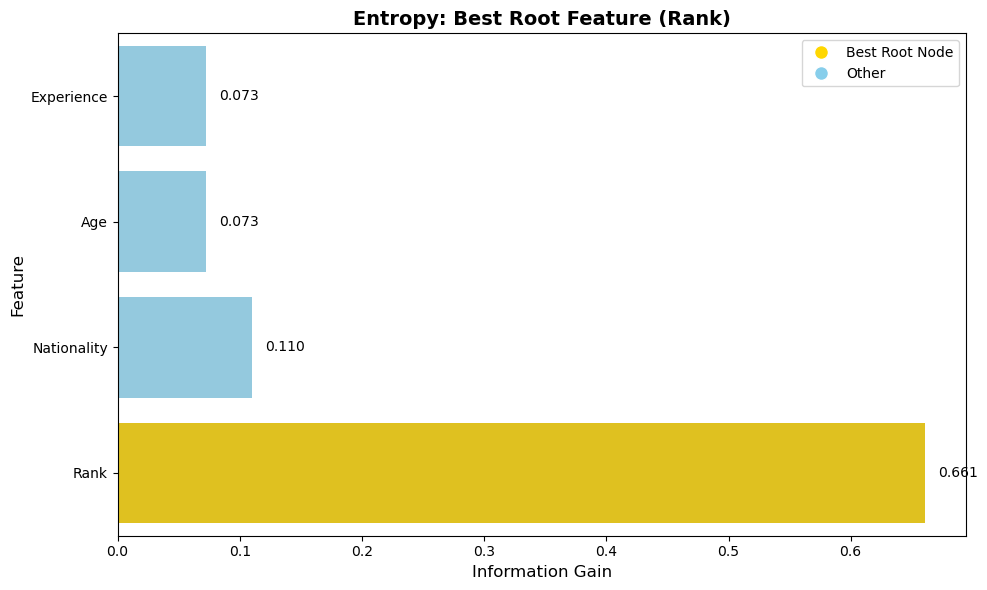

In [9]:
# Barplot: Information Gain per Feature
plt.figure(figsize=(10, 6))
palette = ['gold' if f == best_feature else 'skyblue' for f in ranking_entropy['Feature']]
sns.barplot(
    y='Feature', x='Information_Gain', data=ranking_entropy, palette=palette
)
plt.title(f'Entropy: Best Root Feature ({best_feature})', fontsize=14, fontweight='bold')
plt.xlabel('Information Gain', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.gca().invert_yaxis()
for i, v in enumerate(ranking_entropy['Information_Gain']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Best Root Node', markerfacecolor='gold', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Other', markerfacecolor='skyblue', markersize=10)
], loc='upper right')
plt.tight_layout()
plt.show()


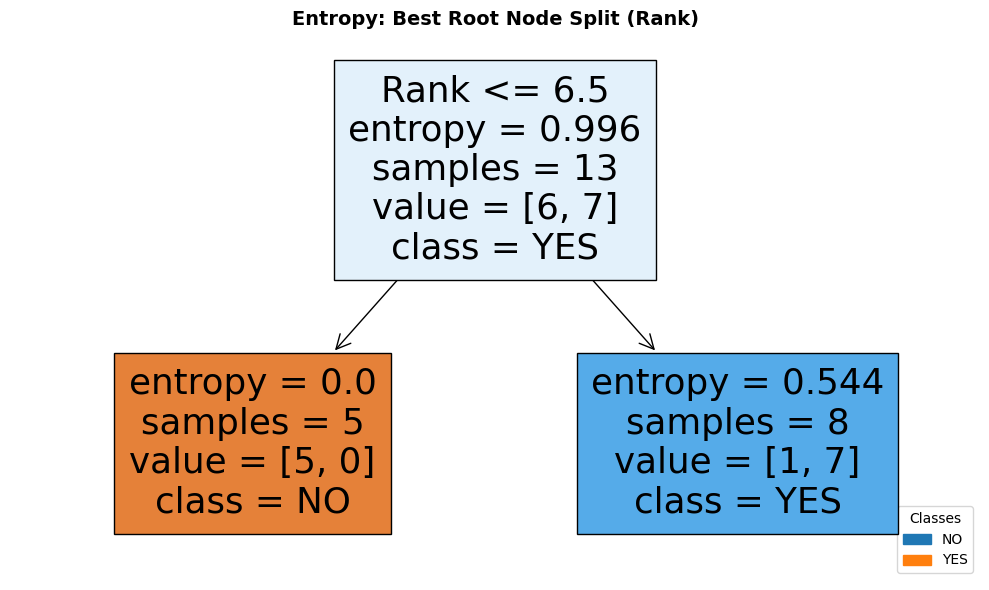

In [10]:
#Visualize Decision Tree (Best Root Node)

clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=42)
clf_entropy.fit(X[[best_feature]], y_encoded)
plt.figure(figsize=(10, 6))
plot_tree(
    clf_entropy, 
    feature_names=[best_feature], 
    filled=True, 
    class_names=go_encoder.classes_
)
plt.title(f'Entropy: Best Root Node Split ({best_feature})', fontsize=14, fontweight='bold')
handles = [
    plt.Rectangle((0,0),1,1, color='C0', label=go_encoder.classes_[0]),
    plt.Rectangle((0,0),1,1, color='C1', label=go_encoder.classes_[1])
]
plt.legend(handles=handles, title='Classes', loc='lower right')
plt.tight_layout()
plt.show()


In [11]:
print("\nEntropy Tree Structure")
print(export_text(clf_entropy, feature_names=[best_feature]))



Entropy Tree Structure
|--- Rank <= 6.50
|   |--- class: 0
|--- Rank >  6.50
|   |--- class: 1



In [12]:
#Ranking Summary & Final Visualization

print("\nRanking by Information Gain (Entropy)")
print(ranking_entropy[['Rank', 'Feature', 'Information_Gain']])



Ranking by Information Gain (Entropy)
   Rank      Feature  Information_Gain
0     1         Rank          0.661226
1     2  Nationality          0.110360
2     3          Age          0.072651
3     4   Experience          0.072651


/var/folders/dy/s9b72v051rqdt2m2dhjrcn1h0000gn/T/ipykernel_51375/1170999297.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


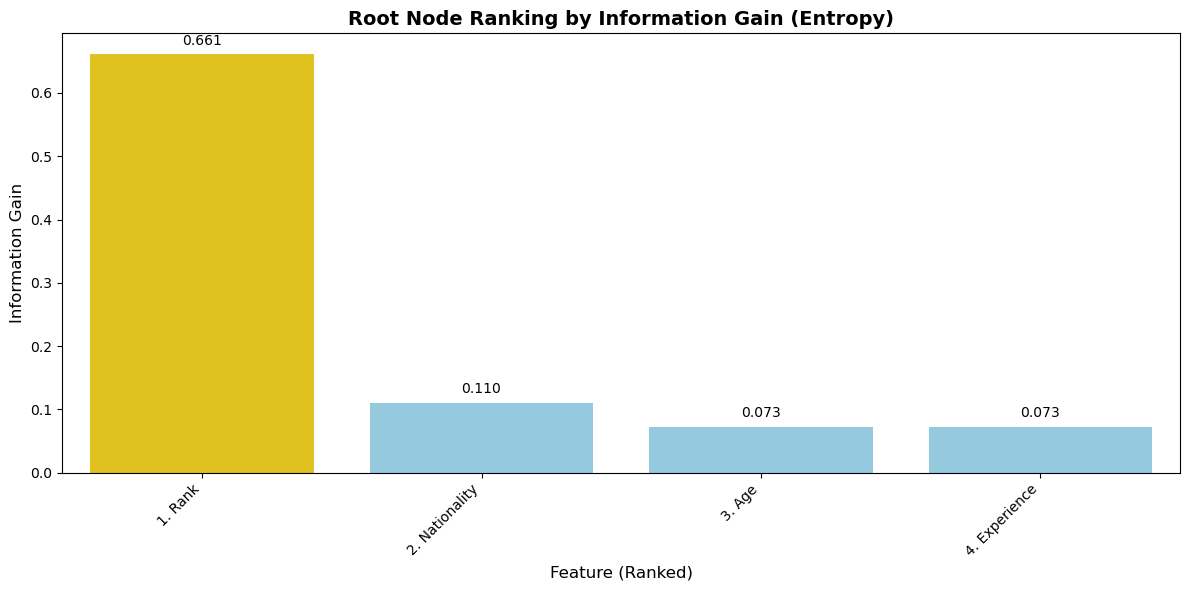

In [13]:
plt.figure(figsize=(12, 6))
palette = ['gold' if feature == best_feature else 'skyblue' for feature in ranking_entropy['Feature']]
sns.barplot(
    x=[f"{i+1}. {name}" for i, name in enumerate(ranking_entropy['Feature'])],
    y=ranking_entropy['Information_Gain'],
    palette=palette
)
plt.title('Root Node Ranking by Information Gain (Entropy)', fontsize=14, fontweight='bold')
plt.xlabel('Feature (Ranked)', fontsize=12)
plt.ylabel('Information Gain', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(ranking_entropy['Information_Gain']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


In [14]:
print("\nDecision Tree Root Node Analysis Summary")
print(f"Best Feature : {best_feature} (Information Gain: {best_info_gain:.4f})")
print("Ranking by Information Gain:\n", ranking_entropy[['Rank', 'Feature', 'Information_Gain']])



Decision Tree Root Node Analysis Summary
Best Feature : Rank (Information Gain: 0.6612)
Ranking by Information Gain:
    Rank      Feature  Information_Gain
0     1         Rank          0.661226
1     2  Nationality          0.110360
2     3          Age          0.072651
3     4   Experience          0.072651
